<>:154: SyntaxWarning: invalid escape sequence '\p'
<>:154: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4465/1935870014.py:154: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title("2. Log-Log Plot: Extracting Fractal Dimension\n$V(r) \propto r^D$", fontweight='bold')


AVENUE 4 - MILESTONE 2: FRACTAL DIMENSION OF THE CAUSAL GRAPH

[1/4] Generating/Loading Causal Graph...
   Total nodes in largest component: 100483

[2/4] Measuring Volume Growth V(r)...
   Processing sample 20/100...
   Processing sample 40/100...
   Processing sample 60/100...
   Processing sample 80/100...
   Processing sample 100/100...

[3/4] Calculating Fractal Dimension...
   Measured Fractal Dimension D = 1.9221
   R-squared of fit = 0.999980

[4/4] Generating Fractal Dimension Figure...

✓ Saved: avenue4_milestone2_fractal_dimension.png


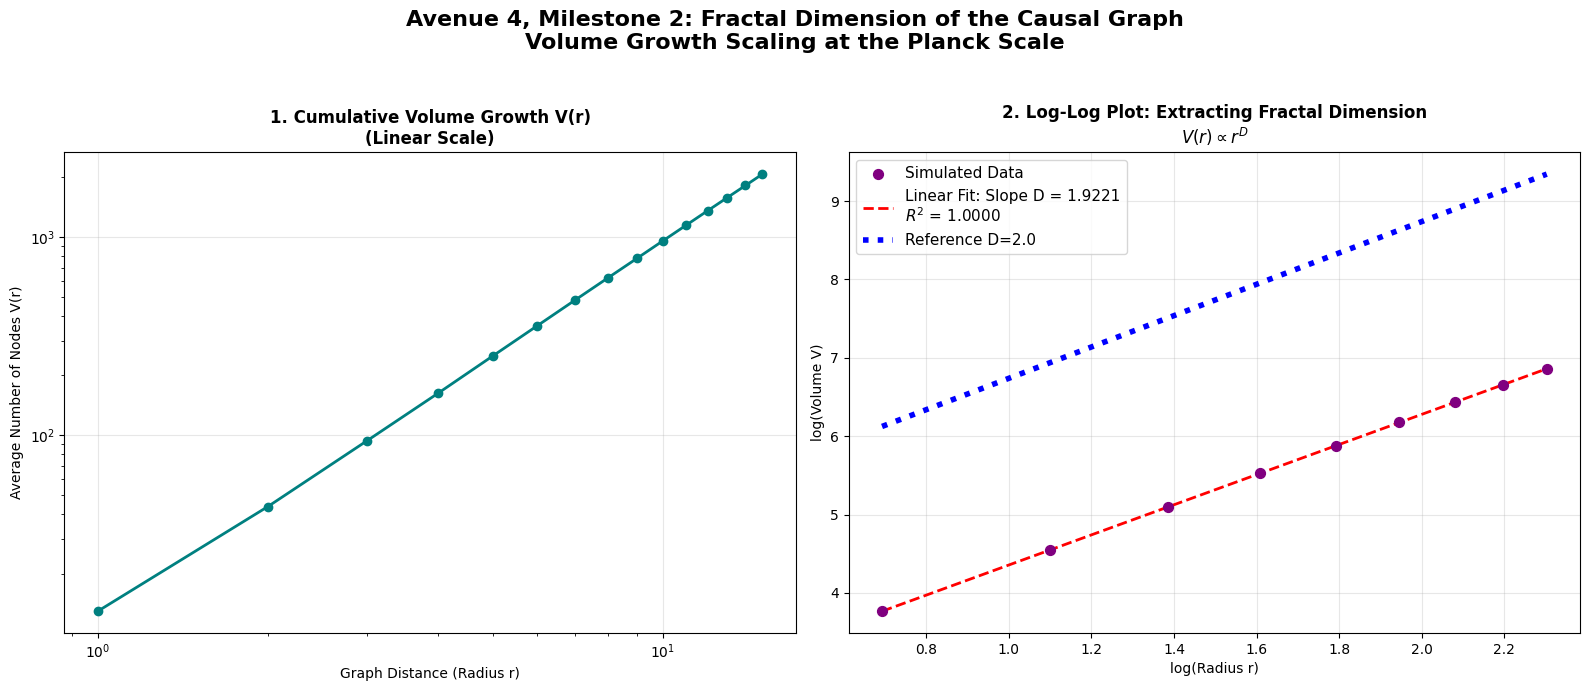


MILESTONE 2 COMPLETE
RESULT: D ≈ 1.9221. The graph exhibits a FRACTIONAL dimension!
This dimension will be tracked under coarse-graining in Milestone 3
to see if it flows to exactly 2.0 at macroscopic scales.


In [6]:
"""
avenue4_milestone2_fractal_dimension.py
========================================
Milestone 2: Measuring the Fractal Dimension of the Causal Graph.
Determines if the Planck-scale causal graph has an integer dimension (D=2)
or a fractional dimension due to the TRB "holes" in the topology.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
from scipy.stats import linregress

print("=" * 70)
print("AVENUE 4 - MILESTONE 2: FRACTAL DIMENSION OF THE CAUSAL GRAPH")
print("=" * 70)

# =============================================================================
# 1. REGENERATE/LOAD GRAPH (Using the same parameters as Milestone 1)
# =============================================================================

def run_and_extract(steps=256, width=512):
    """Quickly regenerates the graph to ensure we have it in memory."""
    base = 10
    reserved_state = 9
    W = np.array([1, 2, 3, 5, 3, 2, 1])
    active_modulus = base - 1

    grid = np.zeros((steps, width), dtype=int)
    center = width // 2
    grid[0, center] = 1

    for t in range(1, steps):
        padded = np.pad(grid[t-1], (3, 3), mode='constant')
        weighted_sum = sum(W[i] * padded[i:i+width] for i in range(7))
        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    G = nx.DiGraph()
    for t in range(steps):
        for x in range(width):
            if grid[t, x] != reserved_state:
                G.add_node((t, x))

    for t in range(steps - 1):
        for x in range(width):
            if grid[t, x] != reserved_state:
                for dx in range(-3, 4):
                    x_next = x + dx
                    if 0 <= x_next < width:
                        if grid[t+1, x_next] != reserved_state:
                            G.add_edge((t, x), (t+1, x_next))
    return G, grid

print("\n[1/4] Generating/Loading Causal Graph...")
causal_graph, grid = run_and_extract()

# Get the Largest Connected Component for accurate dimension measurement
largest_cc = max(nx.weakly_connected_components(causal_graph), key=len)
subgraph = causal_graph.subgraph(largest_cc)
# Convert to undirected for distance measurement (causal flow is directed, but distance is symmetric for dimension)
undirected_subgraph = subgraph.to_undirected()

print(f"   Total nodes in largest component: {len(largest_cc)}")

# =============================================================================
# 2. MEASURE VOLUME GROWTH (V vs r)
# =============================================================================

print("\n[2/4] Measuring Volume Growth V(r)...")
max_radius = 15  # We measure up to distance 15 to avoid edge effects
num_samples = 100  # Sample 100 random source nodes

nodes_list = list(undirected_subgraph.nodes())
sampled_nodes = random.sample(nodes_list, min(num_samples, len(nodes_list)))

volume_growth = np.zeros(max_radius + 1)

for i, source in enumerate(sampled_nodes):
    if (i + 1) % 20 == 0:
        print(f"   Processing sample {i+1}/{num_samples}...")

    # Get shortest path lengths from this source to all reachable nodes
    lengths = nx.single_source_shortest_path_length(undirected_subgraph, source, cutoff=max_radius)

    # Count how many nodes are at each exact distance r
    for r in range(max_radius + 1):
        count_at_r = sum(1 for l in lengths.values() if l == r)
        volume_growth[r] += count_at_r

# Average the volume growth across all sampled nodes
avg_volume = volume_growth / num_samples

# We want cumulative volume V(r) = sum of nodes from distance 0 to r
cumulative_volume = np.cumsum(avg_volume)

# =============================================================================
# 3. CALCULATE FRACTAL DIMENSION (Slope of log-log plot)
# =============================================================================

print("\n[3/4] Calculating Fractal Dimension...")
# Filter out r=0 (log(0) is undefined) and very small r where discrete effects dominate
r_values = np.arange(1, max_radius + 1)
v_values = cumulative_volume[1:]

# Use the linear region for the fit (usually r=2 to r=10 avoids boundary effects)
fit_start = 2
fit_end = 10

log_r = np.log(r_values[fit_start-1:fit_end])
log_v = np.log(v_values[fit_start-1:fit_end])

slope, intercept, r_value, p_value, std_err = linregress(log_r, log_v)
fractal_dimension = slope

print(f"   Measured Fractal Dimension D = {fractal_dimension:.4f}")
print(f"   R-squared of fit = {r_value**2:.6f}")

# =============================================================================
# 4. VISUALIZATION
# =============================================================================

print("\n[4/4] Generating Fractal Dimension Figure...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Avenue 4, Milestone 2: Fractal Dimension of the Causal Graph\nVolume Growth Scaling at the Planck Scale",
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Linear Scale Volume Growth
ax1.plot(r_values, v_values, 'o-', color='teal', linewidth=2, markersize=6)
ax1.set_title("1. Cumulative Volume Growth V(r)\n(Linear Scale)", fontweight='bold')
ax1.set_xlabel("Graph Distance (Radius r)")
ax1.set_ylabel("Average Number of Nodes V(r)")
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

# Panel 2: Log-Log Scale and Dimension Fit
ax2.scatter(log_r, log_v, color='purple', s=50, zorder=5, label='Simulated Data')
fit_line = slope * log_r + intercept
ax2.plot(log_r, fit_line, 'r--', linewidth=2, label=f'Linear Fit: Slope D = {fractal_dimension:.4f}\n$R^2$ = {r_value**2:.4f}')

# Add a reference line for D=2.0
ref_line = 2.0 * log_r + (intercept - 2.0 * np.mean(log_r) + np.mean(log_v)) # Just for visual comparison
# Actually, simpler reference:
#ax2.plot(log_r, 2.0 * log_r + intercept - 2.0*np.mean(log_r) + np.mean(log_v), 'g:', alpha=0.5, label='Reference D=2.0')
ax2.plot(log_r, 2.0 * log_r + intercept - 2.0*np.mean(log_r) + np.mean(log_v), 'b:', linewidth=4, alpha=1.0, label='Reference D=2.0')


ax2.set_title("2. Log-Log Plot: Extracting Fractal Dimension\n$V(r) \propto r^D$", fontweight='bold')
ax2.set_xlabel("log(Radius r)")
ax2.set_ylabel("log(Volume V)")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("avenue4_milestone2_fractal_dimension.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue4_milestone2_fractal_dimension.png")
plt.show()

print("\n" + "=" * 70)
print("MILESTONE 2 COMPLETE")
print("=" * 70)
if abs(fractal_dimension - 2.0) < 0.05:
    print(f"RESULT: D ≈ {fractal_dimension:.4f}. The graph is nearly 2-dimensional.")
else:
    print(f"RESULT: D ≈ {fractal_dimension:.4f}. The graph exhibits a FRACTIONAL dimension!")
print("This dimension will be tracked under coarse-graining in Milestone 3")
print("to see if it flows to exactly 2.0 at macroscopic scales.")
print("=" * 70)